In [4]:
# -*- coding: utf-8 -*-
"""
Created on Wed Jan 21 11:04:12 2026

@author: Dr. Vaibhav Kumar
Assistant Professor, DSE, IISERB
"""

import numpy as np
import matplotlib.pyplot as plt

def create_grid(xmin=-2, xmax=2, ymin=-2, ymax=2, resolution=200):
    """
    Creates a 2D mesh grid for visualization.

    This grid is reused across all experiments to ensure
    consistent comparison between different objective functions.
    """
    x = np.linspace(xmin, xmax, resolution)
    y = np.linspace(ymin, ymax, resolution)
    return np.meshgrid(x, y)


def plot_surface_and_contours(X, Y, Z, title):
    """
    Plots both the 3D surface and contour map of a function.

    Surface plot provides geometric intuition,
    contour plot highlights level sets and stationary behavior.
    """
    fig = plt.figure(figsize=(12, 5))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(X, Y, Z, alpha=0.85)
    ax1.set_title(title + " (Surface)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")

    ax2 = fig.add_subplot(122)
    ax2.contour(X, Y, Z, levels=30)
    ax2.set_title(title + " (Contours)")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")

    plt.tight_layout()
    plt.show()

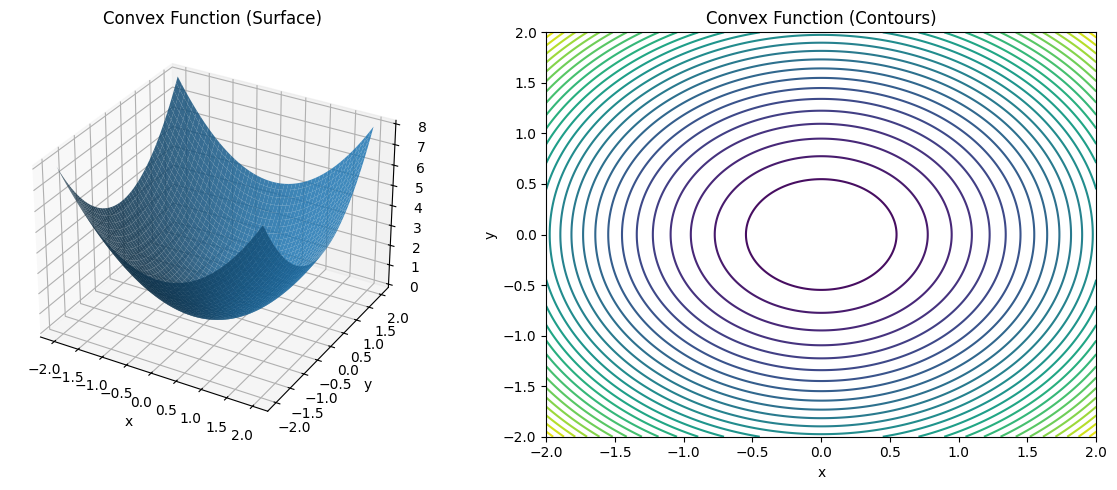

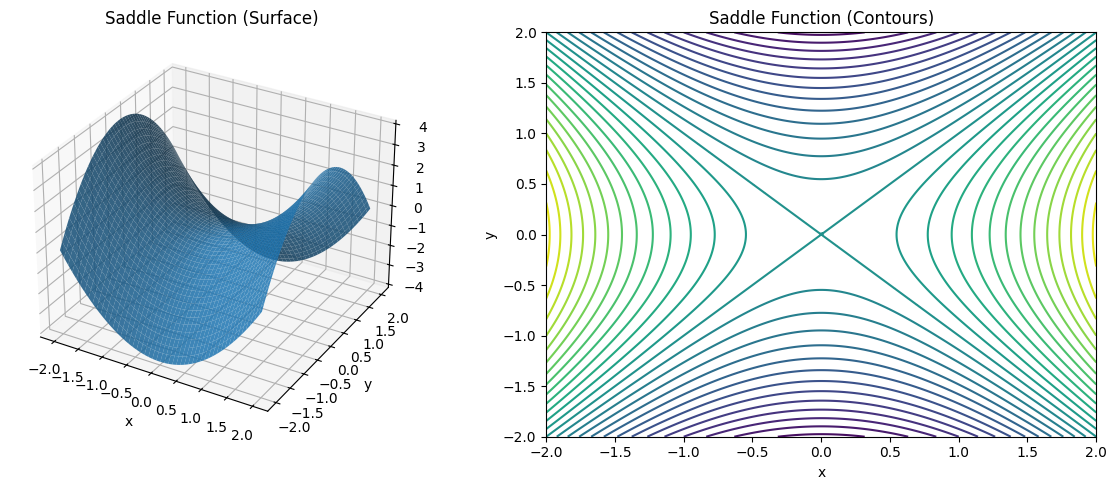

Convex Hessian eigenvalues: [2. 2.]


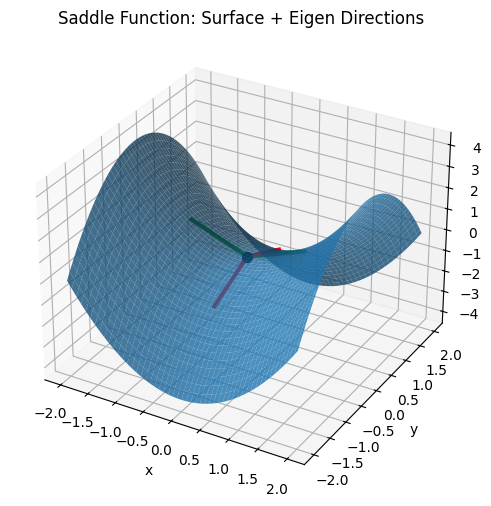

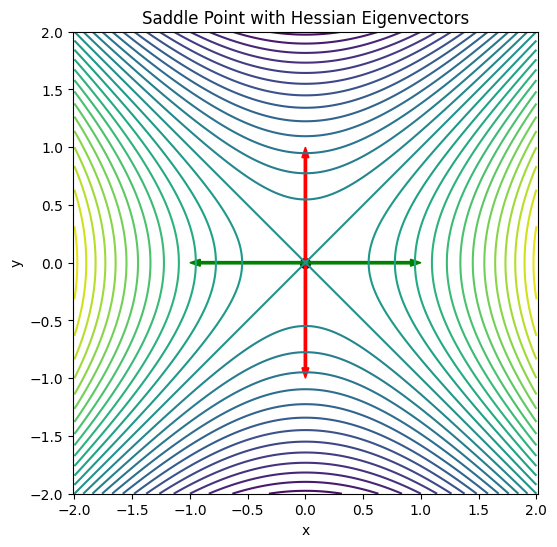

In [5]:
"""
Created on Wed Jan 21 11:04:12 2026

@author: Dr. Vaibhav Kumar
Assistant Professor, DSE, IISERB
"""
import numpy as np
from numpy.linalg import eig
# from common_utils import create_grid, plot_surface_and_contours
import matplotlib.pyplot as plt



def plot_eigen_directions_on_contour(X, Y, Z, H, title,
                                     point=(0.0, 0.0), scale=1.0):
    """
    Overlays Hessian eigenvectors on a contour plot.

    Green arrows  -> positive eigenvalue (upward curvature)
    Red arrows    -> negative eigenvalue (downward curvature)

    This visualization helps identify saddle points geometrically.
    """
    eigvals, eigvecs = eig(H)

    plt.figure(figsize=(6, 6))
    plt.contour(X, Y, Z, levels=30)
    plt.scatter(point[0], point[1], color='black', s=50, label="Stationary point")

    for i in range(len(eigvals)):
        v = eigvecs[:, i]
        if eigvals[i] > 0:
            color = 'green'
            lbl = "Positive curvature direction"
        else:
            color = 'red'
            lbl = "Negative curvature direction"

        # plot both directions ± eigenvector
        plt.arrow(point[0], point[1],
                  scale * v[0], scale * v[1],
                  color=color, width=0.02,
                  length_includes_head=True)
        plt.arrow(point[0], point[1],
                  -scale * v[0], -scale * v[1],
                  color=color, width=0.02,
                  length_includes_head=True)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.show()

def plot_saddle_surface_with_eigenvectors(X, Y, Z, H,
                                          point=(0.0, 0.0),
                                          scale=1.0,
                                          title="Saddle Surface with Eigen Directions"):
    """
    Plots saddle surface and overlays Hessian eigenvector directions
    at the stationary point.

    Green  -> positive eigenvalue (upward curvature)
    Red    -> negative eigenvalue (downward curvature)
    """
    eigvals, eigvecs = eig(H)

    x0, y0 = point
    z0 = 0.0  # for saddle centered at origin

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Surface
    ax.plot_surface(X, Y, Z, alpha=0.8)

    # Stationary point
    ax.scatter(x0, y0, z0, color='black', s=50)

    # Eigenvector directions
    for i in range(len(eigvals)):
        v = eigvecs[:, i]

        if eigvals[i] > 0:
            color = 'green'
        else:
            color = 'red'

        # line in +v direction
        xs = [x0, x0 + scale * v[0]]
        ys = [y0, y0 + scale * v[1]]
        zs = [z0, (x0 + scale * v[0])**2 - (y0 + scale * v[1])**2]

        # line in -v direction
        xs_m = [x0, x0 - scale * v[0]]
        ys_m = [y0, y0 - scale * v[1]]
        zs_m = [z0, (x0 - scale * v[0])**2 - (y0 - scale * v[1])**2]

        ax.plot(xs, ys, zs, color=color, linewidth=3)
        ax.plot(xs_m, ys_m, zs_m, color=color, linewidth=3)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")

    plt.show()


# ------------------------------------------------------------
# Convex Objective
# ------------------------------------------------------------

def f_convex(x, y):
    """
    Convex objective with a unique global minimum.

    f(x, y) = x^2 + y^2

    Intuition:
    - Curvature is positive in all directions.
    - Hessian is positive definite.
    - Any stationary point is a minimum.

    Try:
    - Add linear terms: x^2 + y^2 + x
    - Observe how minimum shifts but convexity remains.
    """
    return x**2 + y**2


# ------------------------------------------------------------
# Saddle Objective
# ------------------------------------------------------------

def f_saddle(x, y):
    """
    Saddle-point objective.

    f(x, y) = x^2 - y^2

    Intuition:
    - Along x-axis: behaves like x^2 (minimum)
    - Along y-axis: behaves like -y^2 (maximum)
    - Mixed curvature → saddle point at (0,0)

    Experiment 1: Flip one sign and check saddles
    - Change to x^2 + y^2
    - Change to -x^2 - y^2

    Experiment 2: Make curvature asymmetric
    f(x, y) = 5*x**2 - y**2
    Observe
    Steeper bowl along x
    Flatter along y
    Still a saddle
    Experiment 3: Gradually remove saddle
    f(x, y) = x**2 - ε*y**2
    ε = 1, 0.1, 0.01, 0.001
    Observe

    Saddle becomes “almost flat” in y
    Optimization algorithms slow down
    Key insight
    Saddles with weak curvature are hard for gradient-based methods.

    Experiment 4:Semidefinite Case -> wwhen does flat become curved?
    f(x, y) = x**4 + y**2
    f(x, y) = x**4 + ε*x**2 + y**2 # Add a tiny quadratic term
    try ε = 0, 0.01, 0.1
    Observe

    At ε = 0 → flat direction
    ε > 0 → clear bowl appears
    Hessian becomes positive definite
    """
    return x**2 - y**2


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

X, Y = create_grid()

plot_surface_and_contours(X, Y, f_convex(X, Y), "Convex Function")
plot_surface_and_contours(X, Y, f_saddle(X, Y), "Saddle Function")

# ------------------------------------------------------------
# Hessian Analysis at (0,0)
# ------------------------------------------------------------

H_convex = np.array([[2, 0],
                     [0, 2]])

H_saddle = np.array([[2, 0],
                     [0, -2]])

print("Convex Hessian eigenvalues:", eig(H_convex)[0])
# print("Saddle Hessian eigenvalues:", eig(H_saddle)[0])
# ------------------------------------------------------------
# Saddle Surface with Eigenvector Directions
# ------------------------------------------------------------

Z_saddle = f_saddle(X, Y)

plot_saddle_surface_with_eigenvectors(
    X, Y, Z_saddle,
    H_saddle,
    point=(0.0, 0.0),
    scale=1.0,
    title="Saddle Function: Surface + Eigen Directions"
)

# ------------------------------------------------------------
# Eigenvector Visualization for Saddle
# ------------------------------------------------------------

Z_saddle = f_saddle(X, Y)

plot_eigen_directions_on_contour(
    X, Y, Z_saddle,
    H_saddle,
    title="Saddle Point with Hessian Eigenvectors",
    point=(0.0, 0.0),
    scale=1.0
)

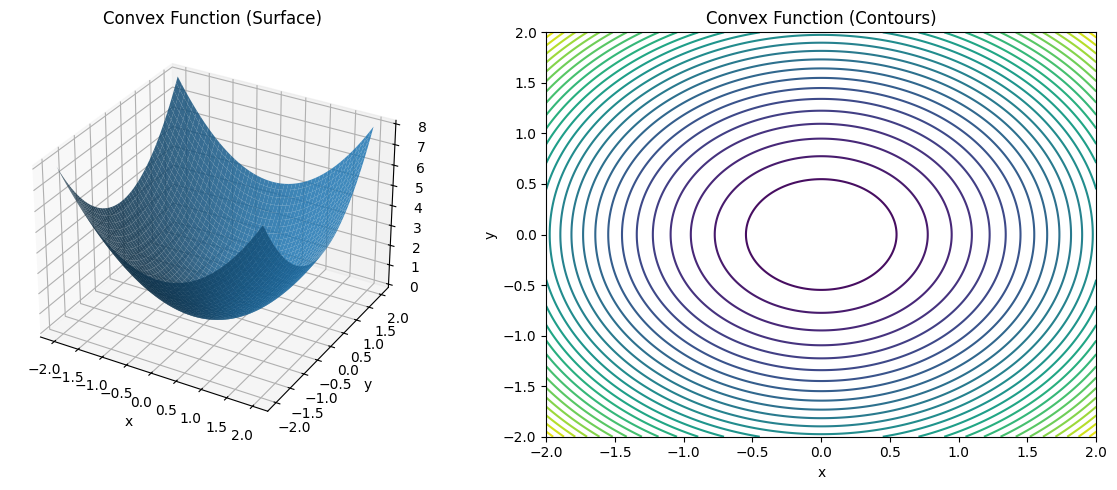

Convex Hessian eigenvalues: [2. 2.]


In [13]:

# ------------------------------------------------------------
# Convex Objective
# ------------------------------------------------------------

def f_convex(x, y):
    """
    Convex objective with a unique global minimum.

    f(x, y) = x^2 + y^2

    Intuition:
    - Curvature is positive in all directions.
    - Hessian is positive definite.
    - Any stationary point is a minimum.

    Try:
    - Add linear terms: x^2 + y^2 + x
    - Observe how minimum shifts but convexity remains.
    """
    return x**2 + y**2 

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

X, Y = create_grid()

plot_surface_and_contours(X, Y, f_convex(X, Y), "Convex Function")

# ------------------------------------------------------------
# Hessian Analysis at (0,0)
# ------------------------------------------------------------

H_convex = np.array([[2, 0],
                     [0, 2]])

print("Convex Hessian eigenvalues:", eig(H_convex)[0])


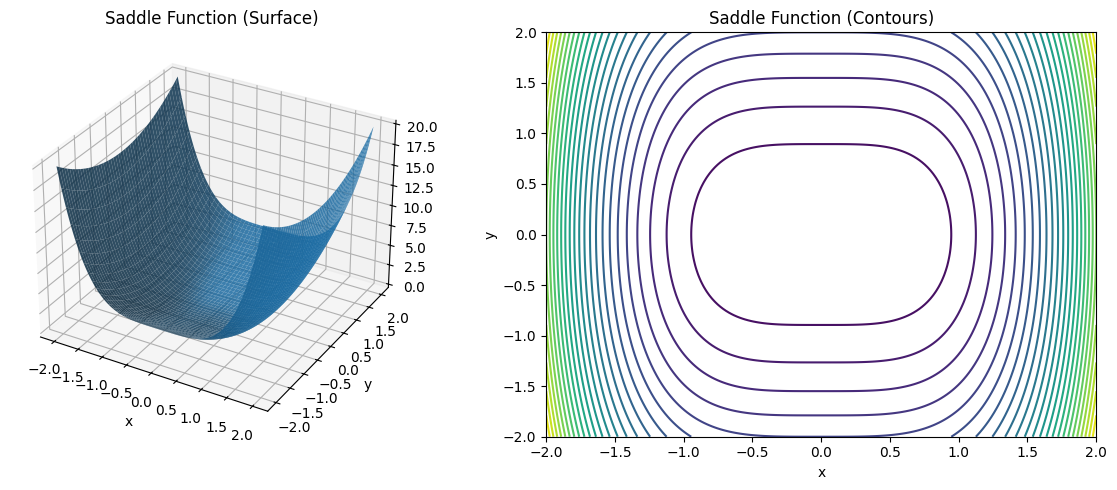

Saddle Hessian eigenvalues: [ 2. -2.]


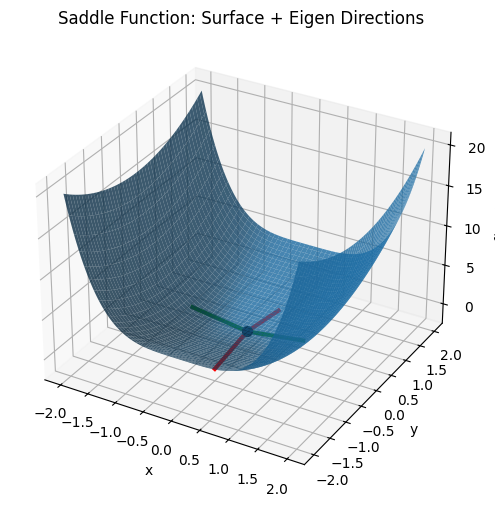

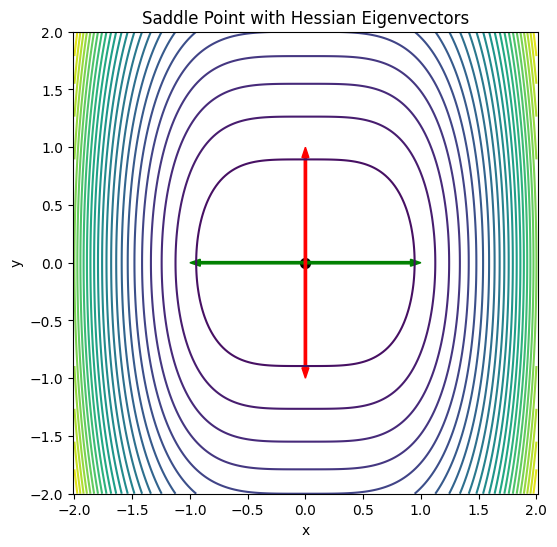

In [24]:
# --------------------------------------------------------
# Saddle Objective
# ------------------------------------------------------------

def f_saddle(x, y):
    """
    Saddle-point objective.

    f(x, y) = x^2 - y^2

    Intuition:
    - Along x-axis: behaves like x^2 (minimum)
    - Along y-axis: behaves like -y^2 (maximum)
    - Mixed curvature → saddle point at (0,0)

    Experiment 1: Flip one sign and check saddles
    - Change to x^2 + y^2
    - Change to -x^2 - y^2

    Experiment 2: Make curvature asymmetric
    f(x, y) = 5*x**2 - y**2
    Observe
    Steeper bowl along x
    Flatter along y
    Still a saddle
    Experiment 3: Gradually remove saddle
    f(x, y) = x**2 - ε*y**2
    ε = 1, 0.1, 0.01, 0.001
    Observe

    Saddle becomes “almost flat” in y
    Optimization algorithms slow down
    Key insight
    Saddles with weak curvature are hard for gradient-based methods.

    Experiment 4:Semidefinite Case -> wwhen does flat become curved?
    f(x, y) = x**4 + y**2
    f(x, y) = x**4 + ε*x**2 + y**2 # Add a tiny quadratic term
    try ε = 0, 0.01, 0.1
    Observe

    At ε = 0 → flat direction
    ε > 0 → clear bowl appears
    Hessian becomes positive definite
    """
    return x**4 + y**2 


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

X, Y = create_grid()

# <!-- plot_surface_and_contours(X, Y, f_convex(X, Y), "Convex Function") -->
plot_surface_and_contours(X, Y, f_saddle(X, Y), "Saddle Function")

# ------------------------------------------------------------
# Hessian Analysis at (0,0)
# ------------------------------------------------------------

H_convex = np.array([[2, 0],
                     [0, 2]])

H_saddle = np.array([[2, 0],
                     [0, -2]])

# print("Convex Hessian eigenvalues:", eig(H_convex)[0])
print("Saddle Hessian eigenvalues:", eig(H_saddle)[0])
# ------------------------------------------------------------
# Saddle Surface with Eigenvector Directions
# ------------------------------------------------------------

Z_saddle = f_saddle(X, Y)

plot_saddle_surface_with_eigenvectors(
    X, Y, Z_saddle,
    H_saddle,
    point=(0.0, 0.0),
    scale=1.0,
    title="Saddle Function: Surface + Eigen Directions"
)

# ------------------------------------------------------------
# Eigenvector Visualization for Saddle
# ------------------------------------------------------------

Z_saddle = f_saddle(X, Y)

plot_eigen_directions_on_contour(
    X, Y, Z_saddle,
    H_saddle,
    title="Saddle Point with Hessian Eigenvectors",
    point=(0.0, 0.0),
    scale=1.0
)